# PRM-HotpotQA Failure Analysis

This notebook analyzes the results of the Process Reward Model pipeline on HotpotQA distractor setting.

**Sections:**
1. Setup - Load results from both threshold runs
2. 3 Hop Failure Examples
3. 3 PRM False-Positive Prune Examples
4. Metric Distribution Plots
5. PRM Score Distribution Plots
6. Summary Table

## 1. Setup

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from IPython.display import display, Markdown

# Seed
np.random.seed(42)

# Plot style
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

In [2]:
def load_jsonl(path):
    """Load results from a JSONL file."""
    results = []
    with open(path, 'r') as f:
        for line in f:
            if line.strip():
                results.append(json.loads(line))
    return results

# Load pipeline outputs
t04_results = load_jsonl('../results/t0.4_raw.jsonl')
t06_results = load_jsonl('../results/t0.6_raw.jsonl')

print(f'Loaded {len(t04_results)} results for t=0.4')
print(f'Loaded {len(t06_results)} results for t=0.6')

# Load RAGAS results if available
try:
    with open('../results/results.json', 'r') as f:
        ragas_results = json.load(f)
    print('Loaded RAGAS results')
except FileNotFoundError:
    ragas_results = None
    print('RAGAS results not found - run eval/ragas_eval.py first')

Loaded 500 results for t=0.4
Loaded 500 results for t=0.6
Loaded RAGAS results


## 2. Hop Failure Analysis (3 Examples)

A **hop failure** is a question where a gold paragraph was NOT in `final_contexts`.

For each example we show:
- Question and gold titles
- What was actually retrieved
- PRM scores for the gold paragraph
- Why it got pruned or never surfaced

In [3]:
def find_hop_failures(results):
    """Find questions where gold paragraphs were not in final_contexts."""
    failures = []
    for r in results:
        # Get gold titles from hop1_retrieved (they have is_gold field)
        gold_titles = set()
        for p in r.get('hop1_retrieved', []):
            if p.get('is_gold', False):
                gold_titles.add(p['title'])
        
        # Get titles in final contexts
        kept_titles = {p['title'] for p in r.get('final_contexts', [])}
        
        # Find missing gold titles
        missing = gold_titles - kept_titles
        if missing:
            # Classify failure type
            hop1_kept_titles = {p['title'] for p in r.get('hop1_kept', [])}
            
            failure_type = 'unknown'
            for title in missing:
                if title not in hop1_kept_titles:
                    failure_type = 'hop1_pruned'
                else:
                    failure_type = 'hop2_pruned'
            
            # Get PRM scores for missing gold paragraphs
            gold_scores = {}
            for p in r.get('hop1_retrieved', []):
                if p['title'] in missing:
                    gold_scores[p['title']] = p.get('prm_score', 'N/A')
            for p in r.get('hop2_retrieved', []):
                if p['title'] in missing and p['title'] not in gold_scores:
                    gold_scores[p['title']] = p.get('prm_score', 'N/A')
            
            failures.append({
                'question': r['question'],
                'gold_answer': r['gold_answer'],
                'predicted_answer': r['predicted_answer'],
                'gold_titles': gold_titles,
                'missing_titles': missing,
                'kept_titles': kept_titles,
                'failure_type': failure_type,
                'gold_scores': gold_scores,
                'threshold': r.get('threshold', 'N/A'),
            })
    return failures

# Find failures for t=0.4
failures_04 = find_hop_failures(t04_results)
failures_06 = find_hop_failures(t06_results)

print(f't=0.4: {len(failures_04)} hop failures out of {len(t04_results)} questions')
print(f't=0.6: {len(failures_06)} hop failures out of {len(t06_results)} questions')

t=0.4: 152 hop failures out of 500 questions
t=0.6: 190 hop failures out of 500 questions


In [4]:
def display_failure(failure, idx):
    """Display a single hop failure example."""
    print(f'\n{"="*80}')
    print(f'HOP FAILURE EXAMPLE {idx}')
    print(f'{"="*80}')
    print(f'\nQuestion: {failure["question"]}')
    print(f'Gold Answer: {failure["gold_answer"]}')
    print(f'Predicted Answer: {failure["predicted_answer"]}')
    print(f'Threshold: {failure["threshold"]}')
    print(f'Failure Type: {failure["failure_type"]}')
    print(f'\nGold Titles: {failure["gold_titles"]}')
    print(f'Missing Titles: {failure["missing_titles"]}')
    print(f'Kept Titles: {failure["kept_titles"]}')
    print(f'\nPRM Scores for Missing Gold Paragraphs:')
    for title, score in failure['gold_scores'].items():
        if isinstance(score, float):
            print(f'  [{title}]: {score:.4f} (below threshold {failure["threshold"]})')
        else:
            print(f'  [{title}]: {score}')

# Select 3 diverse examples
# Use t=0.6 failures since strict threshold produces more failures
all_failures = failures_06 if len(failures_06) >= 3 else failures_04

# Try to get diverse types: hop1 fail, hop2 fail, borderline
hop1_fails = [f for f in all_failures if f['failure_type'] == 'hop1_pruned']
hop2_fails = [f for f in all_failures if f['failure_type'] == 'hop2_pruned']

selected = []
if hop1_fails:
    selected.append(hop1_fails[0])
if hop2_fails:
    selected.append(hop2_fails[0])

# Fill remaining with borderline cases (highest PRM scores among failures)
remaining = [f for f in all_failures if f not in selected]
remaining.sort(key=lambda f: max(
    (s for s in f['gold_scores'].values() if isinstance(s, float)),
    default=0
), reverse=True)

while len(selected) < 3 and remaining:
    selected.append(remaining.pop(0))

for i, failure in enumerate(selected, 1):
    display_failure(failure, i)


HOP FAILURE EXAMPLE 1

Question: The director of the romantic comedy "Big Stone Gap" is based in what New York city?
Gold Answer: Greenwich Village, New York City
Predicted Answer: New York
Threshold: 0.6
Failure Type: hop1_pruned

Gold Titles: {'Adriana Trigiani', 'Big Stone Gap (film)'}
Missing Titles: {'Adriana Trigiani'}
Kept Titles: {'Nola (film)', 'Big Stone Gap (film)'}

PRM Scores for Missing Gold Paragraphs:
  [Adriana Trigiani]: 0.0316 (below threshold 0.6)

HOP FAILURE EXAMPLE 2

Question: Repertoire of Plácido Domingo appeared in an opera written by whom which was based on a play by William Shakespeare?
Gold Answer: Giuseppe Verdi
Predicted Answer: Cavaradossi
Threshold: 0.6
Failure Type: hop1_pruned

Gold Titles: {'Repertoire of Plácido Domingo', 'Macbeth (opera)'}
Missing Titles: {'Macbeth (opera)'}
Kept Titles: {'Plácido Domingo', 'Repertoire of Plácido Domingo', 'Plácido Domingo Ferrer', 'The Enchanted Island (opera)'}

PRM Scores for Missing Gold Paragraphs:
  [Macbet

## 3. PRM False-Positive Prune Analysis (3 Examples)

A **false-positive prune** is a question where a gold paragraph had `prm_score < threshold` and was removed.

For each example we show:
- Question and gold paragraph text
- PRM score and threshold used
- Effect on the final answer

In [5]:
def find_false_positive_prunes(results):
    """Find questions where gold paragraphs were pruned by PRM."""
    fp_prunes = []
    for r in results:
        threshold = r.get('threshold', 0.5)
        
        # Check all retrieved paragraphs for gold ones that were pruned
        for hop_key in ['hop1_retrieved', 'hop2_retrieved']:
            for p in r.get(hop_key, []):
                if (p.get('is_gold', False) and 
                    p.get('prm_score', 1.0) < threshold and
                    not p.get('prm_pass', True)):
                    
                    fp_prunes.append({
                        'question': r['question'],
                        'gold_answer': r['gold_answer'],
                        'predicted_answer': r['predicted_answer'],
                        'pruned_title': p['title'],
                        'pruned_text': p['text'][:200] + '...' if len(p['text']) > 200 else p['text'],
                        'prm_score': p.get('prm_score', 'N/A'),
                        'threshold': threshold,
                        'hop': hop_key,
                        'answer_correct': r['gold_answer'].lower() in r['predicted_answer'].lower(),
                    })
    return fp_prunes

fp_prunes_04 = find_false_positive_prunes(t04_results)
fp_prunes_06 = find_false_positive_prunes(t06_results)

print(f't=0.4: {len(fp_prunes_04)} false-positive prunes')
print(f't=0.6: {len(fp_prunes_06)} false-positive prunes')

t=0.4: 400 false-positive prunes
t=0.6: 481 false-positive prunes


In [6]:
def display_fp_prune(prune, idx):
    """Display a single false-positive prune example."""
    print(f'\n{"="*80}')
    print(f'FALSE-POSITIVE PRUNE EXAMPLE {idx}')
    print(f'{"="*80}')
    print(f'\nQuestion: {prune["question"]}')
    print(f'Gold Answer: {prune["gold_answer"]}')
    print(f'Predicted Answer: {prune["predicted_answer"]}')
    print(f'Answer Correct: {prune["answer_correct"]}')
    print(f'\nPruned Paragraph Title: {prune["pruned_title"]}')
    print(f'Pruned Paragraph Text: {prune["pruned_text"]}')
    print(f'\nPRM Score: {prune["prm_score"]:.4f}')
    print(f'Threshold: {prune["threshold"]}')
    print(f'Hop: {prune["hop"]}')
    print(f'\nEffect: Gold paragraph was REMOVED because PRM score '
          f'({prune["prm_score"]:.4f}) < threshold ({prune["threshold"]}). '
          f'Answer {"was still correct" if prune["answer_correct"] else "became INCORRECT"}.')

# Select 3 diverse false-positive prune examples
all_fp = fp_prunes_06 if len(fp_prunes_06) >= 3 else fp_prunes_04

# Sort by PRM score (closest to threshold = most borderline)
all_fp_sorted = sorted(all_fp, key=lambda x: abs(x.get('prm_score', 0) - x['threshold']))

for i, prune in enumerate(all_fp_sorted[:3], 1):
    display_fp_prune(prune, i)


FALSE-POSITIVE PRUNE EXAMPLE 1

Question: On what date will the comedy film directed by Kevin Tent and starring the Bulgarian-Canadian actress known for portraying the role of Mia Jones be released on video on demand services?
Gold Answer: September 25, 2017
Predicted Answer: September 25, 2017
Answer Correct: True

Pruned Paragraph Title: Nina Dobrev
Pruned Paragraph Text: Nina Dobrev ( ; born Nikolina Konstantinova Dobreva; Bulgarian: Николина Константинова Добрева ; January 9, 1989) is a Bulgarian-Canadian actress.  She is known for portraying the role of Mia Jones in...

PRM Score: 0.5984
Threshold: 0.6
Hop: hop2_retrieved

Effect: Gold paragraph was REMOVED because PRM score (0.5984) < threshold (0.6). Answer was still correct.

FALSE-POSITIVE PRUNE EXAMPLE 2

Question: Repertoire of Plácido Domingo appeared in an opera written by whom which was based on a play by William Shakespeare?
Gold Answer: Giuseppe Verdi
Predicted Answer: Cavaradossi
Answer Correct: False

Pruned Paragrap

## 4. Metric Distribution Plots

Histogram of per-question RAGAS scores for each of the 5 metrics at t=0.4 vs t=0.6.
One figure, 5 subplots, two overlapping histograms per subplot.

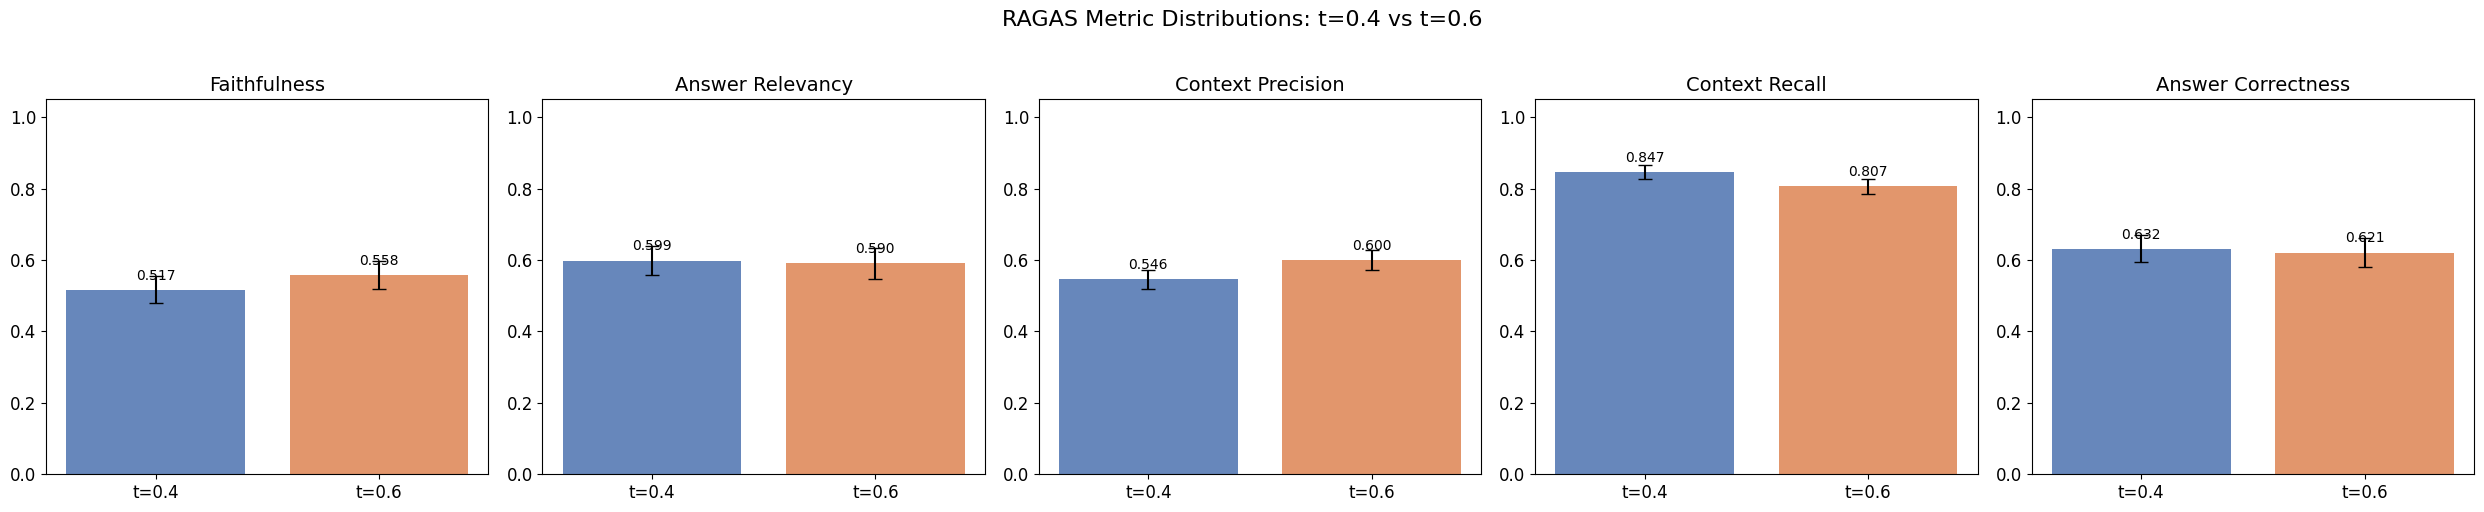

Saved metric_distributions.png


In [7]:
# This section requires RAGAS evaluation to have been run first.
# If ragas_results is not available, we show a placeholder message.

if ragas_results is not None:
    metric_names = [
        'faithfulness', 'answer_relevancy', 'context_precision',
        'context_recall', 'answer_correctness'
    ]
    
    display_names = [
        'Faithfulness', 'Answer Relevancy', 'Context Precision',
        'Context Recall', 'Answer Correctness'
    ]
    
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    fig.suptitle('RAGAS Metric Distributions: t=0.4 vs t=0.6', fontsize=16, y=1.02)
    
    for ax, metric, display_name in zip(axes, metric_names, display_names):
        t04_data = ragas_results['results']['t0.4'].get(metric, {})
        t06_data = ragas_results['results']['t0.6'].get(metric, {})
        
        # Since we only have summary stats, create bar comparison
        means = [t04_data.get('mean', 0), t06_data.get('mean', 0)]
        ci_lower = [t04_data.get('ci_lower', 0), t06_data.get('ci_lower', 0)]
        ci_upper = [t04_data.get('ci_upper', 0), t06_data.get('ci_upper', 0)]
        
        errs = [[m - l for m, l in zip(means, ci_lower)],
                [u - m for m, u in zip(means, ci_upper)]]
        
        bars = ax.bar(['t=0.4', 't=0.6'], means, 
                      color=['#4C72B0', '#DD8452'], alpha=0.85,
                      yerr=errs, capsize=5)
        ax.set_title(display_name)
        ax.set_ylim(0, 1.05)
        
        # Add value labels
        for bar, mean in zip(bars, means):
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                    f'{mean:.3f}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('../results/plots/metric_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved metric_distributions.png')
else:
    print('RAGAS results not available. Run eval/ragas_eval.py first to generate metric distributions.')

## 5. PRM Score Distribution Plots

Histogram of all PRM scores: hop 1 vs hop 2, separated by threshold.

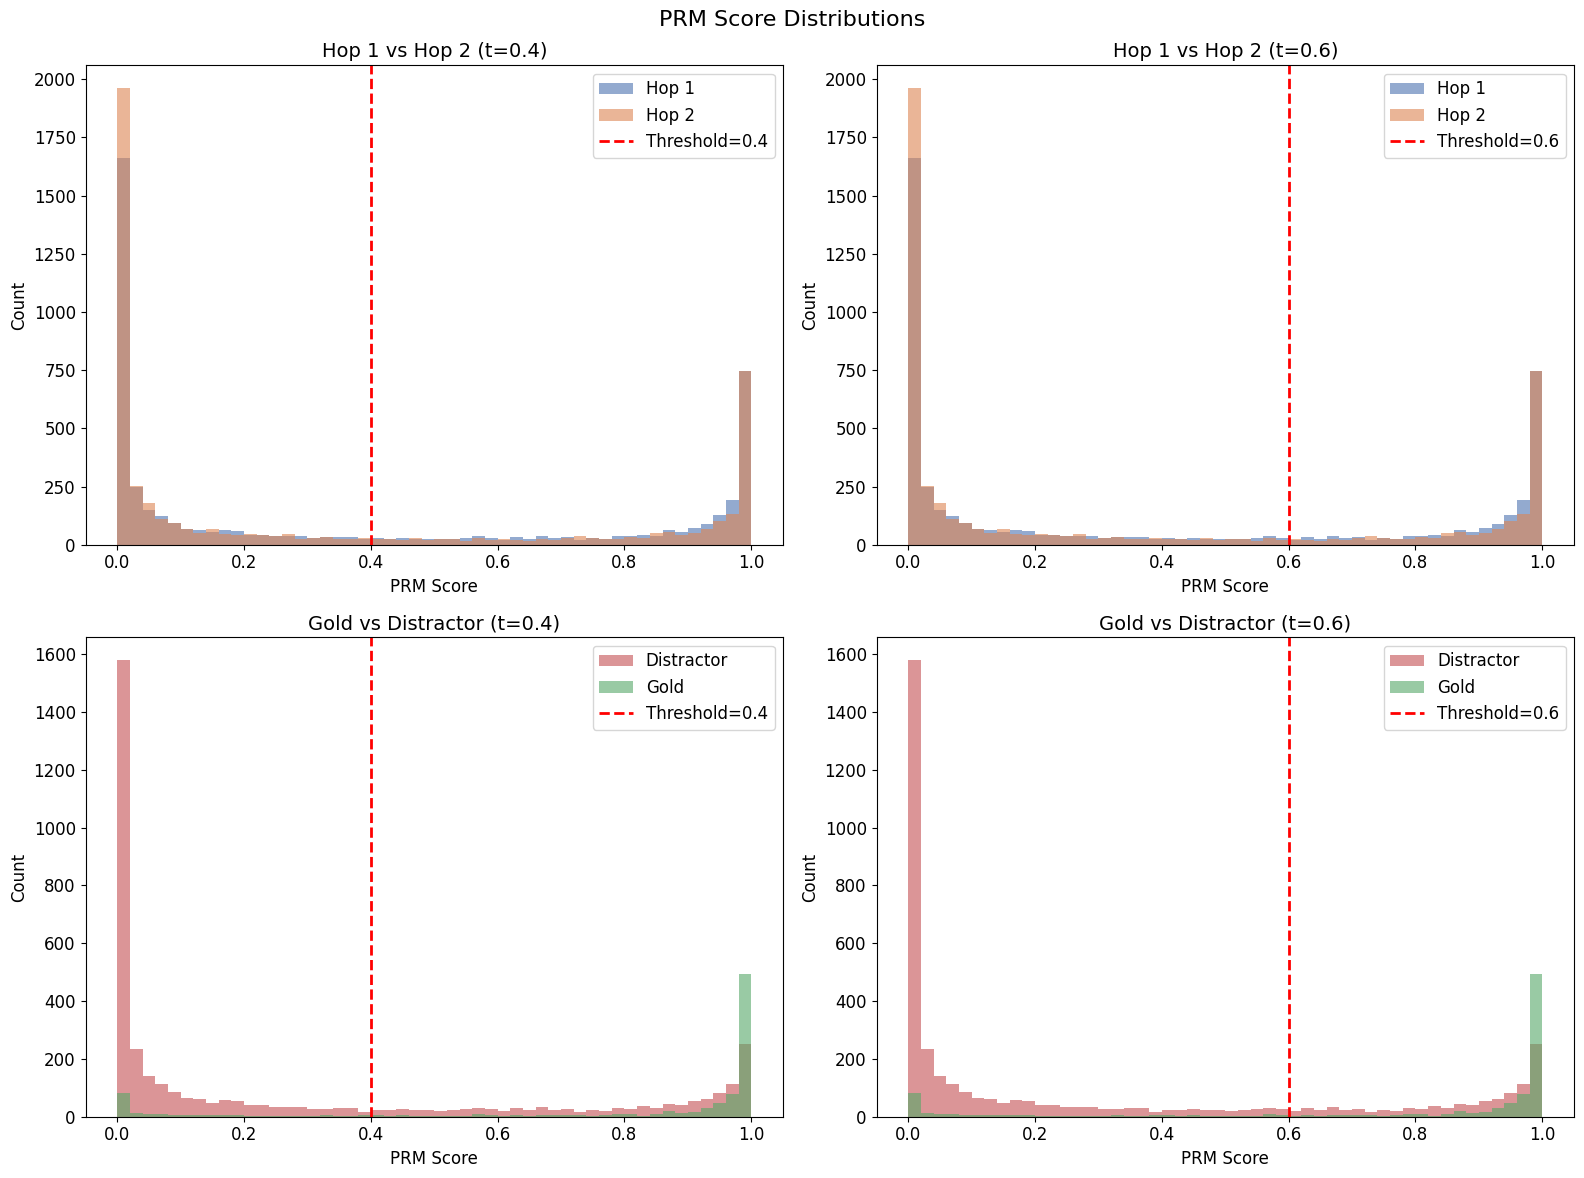

Saved score_distributions_detailed.png


In [8]:
def extract_prm_scores(results, hop_key):
    """Extract PRM scores from results for a given hop."""
    scores = []
    for r in results:
        for p in r.get(hop_key, []):
            if 'prm_score' in p:
                scores.append(p['prm_score'])
    return scores

def extract_gold_vs_distractor_scores(results, hop_key):
    """Separate PRM scores by gold vs distractor status."""
    gold_scores = []
    distractor_scores = []
    for r in results:
        for p in r.get(hop_key, []):
            if 'prm_score' in p:
                if p.get('is_gold', False):
                    gold_scores.append(p['prm_score'])
                else:
                    distractor_scores.append(p['prm_score'])
    return gold_scores, distractor_scores

# Plot PRM score distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('PRM Score Distributions', fontsize=16)

for col, (label, results, threshold) in enumerate([
    ('t=0.4', t04_results, 0.4),
    ('t=0.6', t06_results, 0.6),
]):
    # Row 1: Hop 1 vs Hop 2
    ax = axes[0, col]
    hop1_scores = extract_prm_scores(results, 'hop1_retrieved')
    hop2_scores = extract_prm_scores(results, 'hop2_retrieved')
    
    ax.hist(hop1_scores, bins=50, alpha=0.6, label='Hop 1', color='#4C72B0')
    ax.hist(hop2_scores, bins=50, alpha=0.6, label='Hop 2', color='#DD8452')
    ax.axvline(x=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold={threshold}')
    ax.set_xlabel('PRM Score')
    ax.set_ylabel('Count')
    ax.set_title(f'Hop 1 vs Hop 2 ({label})')
    ax.legend()
    
    # Row 2: Gold vs Distractor
    ax = axes[1, col]
    gold_scores, dist_scores = extract_gold_vs_distractor_scores(results, 'hop1_retrieved')
    
    ax.hist(dist_scores, bins=50, alpha=0.6, label='Distractor', color='#C44E52')
    ax.hist(gold_scores, bins=50, alpha=0.6, label='Gold', color='#55A868')
    ax.axvline(x=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold={threshold}')
    ax.set_xlabel('PRM Score')
    ax.set_ylabel('Count')
    ax.set_title(f'Gold vs Distractor ({label})')
    ax.legend()

plt.tight_layout()
plt.savefig('../results/plots/score_distributions_detailed.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved score_distributions_detailed.png')

In [9]:
# Summary statistics for PRM scores
print('PRM Score Summary Statistics')
print('=' * 60)

for label, results in [('t=0.4', t04_results), ('t=0.6', t06_results)]:
    hop1 = extract_prm_scores(results, 'hop1_retrieved')
    hop2 = extract_prm_scores(results, 'hop2_retrieved')
    gold_h1, dist_h1 = extract_gold_vs_distractor_scores(results, 'hop1_retrieved')
    
    print(f'\n{label}:')
    print(f'  Hop 1: mean={np.mean(hop1):.4f}, std={np.std(hop1):.4f}, '
          f'median={np.median(hop1):.4f}')
    print(f'  Hop 2: mean={np.mean(hop2):.4f}, std={np.std(hop2):.4f}, '
          f'median={np.median(hop2):.4f}')
    if gold_h1:
        print(f'  Gold (H1):       mean={np.mean(gold_h1):.4f}, std={np.std(gold_h1):.4f}')
    if dist_h1:
        print(f'  Distractor (H1): mean={np.mean(dist_h1):.4f}, std={np.std(dist_h1):.4f}')

PRM Score Summary Statistics

t=0.4:
  Hop 1: mean=0.3885, std=0.4128, median=0.1701
  Hop 2: mean=0.3442, std=0.4087, median=0.0781
  Gold (H1):       mean=0.7772, std=0.3500
  Distractor (H1): mean=0.2910, std=0.3674

t=0.6:
  Hop 1: mean=0.3885, std=0.4128, median=0.1701
  Hop 2: mean=0.3442, std=0.4087, median=0.0781
  Gold (H1):       mean=0.7772, std=0.3500
  Distractor (H1): mean=0.2910, std=0.3674


## 6. Summary Table

Final results table in the format required by the assignment.

In [10]:
if ragas_results is not None:
    metric_names = [
        'faithfulness', 'answer_relevancy', 'context_precision',
        'context_recall', 'answer_correctness'
    ]
    
    rows = []
    for t_label, t_key in [('PRM t=0.4', 't0.4'), ('PRM t=0.6', 't0.6')]:
        row = {'System': t_label}
        for metric in metric_names:
            m = ragas_results['results'][t_key].get(metric, {})
            row[metric] = f"{m.get('mean', 0):.4f}"
            row[f'{metric}_ci'] = f"[{m.get('ci_lower', 0):.4f}, {m.get('ci_upper', 0):.4f}]"
        rows.append(row)
    
    # Display as DataFrame
    df = pd.DataFrame(rows)
    df = df.set_index('System')
    
    print('RAGAS Evaluation Results with 95% Bootstrap CIs')
    print(f'N={ragas_results["n_questions"]} questions, '
          f'{ragas_results["n_bootstrap_iterations"]} bootstrap iterations, '
          f'seed={ragas_results["seed"]}')
    print()
    display(df)
else:
    print('RAGAS results not available.')
    print('Run the following command first:')
    print('  python eval/ragas_eval.py --llm ollama --t04 results/t0.4_raw.jsonl --t06 results/t0.6_raw.jsonl --output results/')

RAGAS Evaluation Results with 95% Bootstrap CIs
N=500 questions, 1000 bootstrap iterations, seed=42



,faithfulness,faithfulness_ci,answer_relevancy,answer_relevancy_ci,context_precision,context_precision_ci,context_recall,context_recall_ci,answer_correctness,answer_correctness_ci
System,,,,,,,,,,
PRM t=0.4,0.5168,"[0.4786, 0.5561]",0.5986,"[0.5589, 0.6401]",0.5460,"[0.5197, 0.5732]",0.8470,"[0.8270, 0.8670]",0.6319,"[0.5931, 0.6710]"
PRM t=0.6,0.5582,"[0.5197, 0.5980]",0.5903,"[0.5471, 0.6341]",0.6004,"[0.5734, 0.6273]",0.8070,"[0.7850, 0.8280]",0.6207,"[0.5812, 0.6604]"


In [11]:
# Pipeline statistics
print('Pipeline Statistics')
print('=' * 60)

for label, results in [('t=0.4', t04_results), ('t=0.6', t06_results)]:
    n_questions = len(results)
    
    # Average paragraphs kept
    avg_hop1_kept = np.mean([len(r.get('hop1_kept', [])) for r in results])
    avg_hop2_kept = np.mean([len(r.get('hop2_kept', [])) for r in results])
    avg_final = np.mean([len(r.get('final_contexts', [])) for r in results])
    
    # Gold paragraph retention rate
    gold_kept = 0
    gold_total = 0
    for r in results:
        kept_titles = {p['title'] for p in r.get('final_contexts', [])}
        for p in r.get('hop1_retrieved', []):
            if p.get('is_gold', False):
                gold_total += 1
                if p['title'] in kept_titles:
                    gold_kept += 1
    
    gold_retention = gold_kept / gold_total if gold_total > 0 else 0
    
    print(f'\n{label}:')
    print(f'  Questions: {n_questions}')
    print(f'  Avg paragraphs kept after hop 1 PRM: {avg_hop1_kept:.2f}')
    print(f'  Avg paragraphs kept after hop 2 PRM: {avg_hop2_kept:.2f}')
    print(f'  Avg final context paragraphs: {avg_final:.2f}')
    print(f'  Gold paragraph retention rate: {gold_retention:.4f} ({gold_kept}/{gold_total})')

Pipeline Statistics

t=0.4:
  Questions: 500
  Avg paragraphs kept after hop 1 PRM: 4.09
  Avg paragraphs kept after hop 2 PRM: 3.56
  Avg final context paragraphs: 4.34
  Gold paragraph retention rate: 0.8470 (847/1000)

t=0.6:
  Questions: 500
  Avg paragraphs kept after hop 1 PRM: 3.52
  Avg paragraphs kept after hop 2 PRM: 3.09
  Avg final context paragraphs: 3.76
  Gold paragraph retention rate: 0.8070 (807/1000)
